[INFO] GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[INFO] Using GPU: /physical_device:GPU:0
Mounted at /content/drive
[INFO] Dataset path: /content/drive/MyDrive/Datasets Models Projects/Faces
26-04-26 22:22:36 - Directory /root/.deepface has been created
26-04-26 22:22:36 - Directory /root/.deepface/weights has been created
[INFO] Found 31 celebrities
       Labels: ['Akshay Kumar', 'Alexandra Daddario', 'Alia Bhatt', 'Amitabh Bachchan', 'Andy Samberg', 'Anushka Sharma', 'Billie Eilish', 'Brad Pitt'] ...

[INFO] Building gallery with ArcFace embeddings …


Gallery:   0%|          | 0/31 [00:00<?, ?it/s]

26-04-26 22:22:45 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5

  0%|          | 0.00/137M [00:00<?, ?B/s]
  8%|▊         | 11.0M/137M [00:00<00:02, 46.5MB/s]
 16%|█▌        | 21.5M/137M [00:00<00:02, 45.4MB/s]
 23%|██▎       | 32.0M/137M [00:00<00:02, 42.7MB/s]
 31%|███       | 42.5M/137M [00:00<00:02, 43.9MB/s]
 39%|███▊      | 53.0M/137M [00:01<00:01, 43.7MB/s]
 46%|████▋     | 63.4M/137M [00:01<00:01, 43.9MB/s]
 54%|█████▍    | 73.9M/137M [00:01<00:01, 44.0MB/s]
 62%|██████▏   | 84.4M/137M [00:01<00:01, 43.8MB/s]
 69%|██████▉   | 94.9M/137M [00:02<00:00, 44.1MB/s]
 77%|███████▋  | 105M/137M [00:02<00:00, 43.9MB/s] 
 85%|████████▍ | 116M/137M [00:02<00:00, 42.3MB/s]
 92%|█████████▏| 126M/137M [00:02<00:00, 43.3MB/s]
100%|██████████| 137M/137M [00:03<00:00, 43.6MB/s]
Gallery: 100%|██████████| 31/31 [13:41<00:00, 26.48s/it]


[INFO] Gallery built in 821.0s  (31 celebs)

[INFO] Testing on 10 random images …

[01] True=Tom Cruise                Pred=Marmik                    Sim=0.4606  ✗ WRONG
[02] True=Andy Samberg              Pred=Andy Samberg              Sim=0.5996  ✓ CORRECT
[03] True=Alexandra Daddario        Pred=Alexandra Daddario        Sim=0.8807  ✓ CORRECT
[04] True=Courtney Cox              Pred=Courtney Cox              Sim=0.8355  ✓ CORRECT
[05] True=Claire Holt               Pred=Claire Holt               Sim=0.7516  ✓ CORRECT
[06] True=Charlize Theron           Pred=Charlize Theron           Sim=0.8854  ✓ CORRECT
[07] True=Anushka Sharma            Pred=Anushka Sharma            Sim=0.7517  ✓ CORRECT
[08] True=Andy Samberg              Pred=Andy Samberg              Sim=0.6807  ✓ CORRECT
[09] True=Virat Kohli               Pred=Virat Kohli               Sim=0.7844  ✓ CORRECT
[10] True=Natalie Portman           Pred=Natalie Portman           Sim=0.8820  ✓ CORRECT


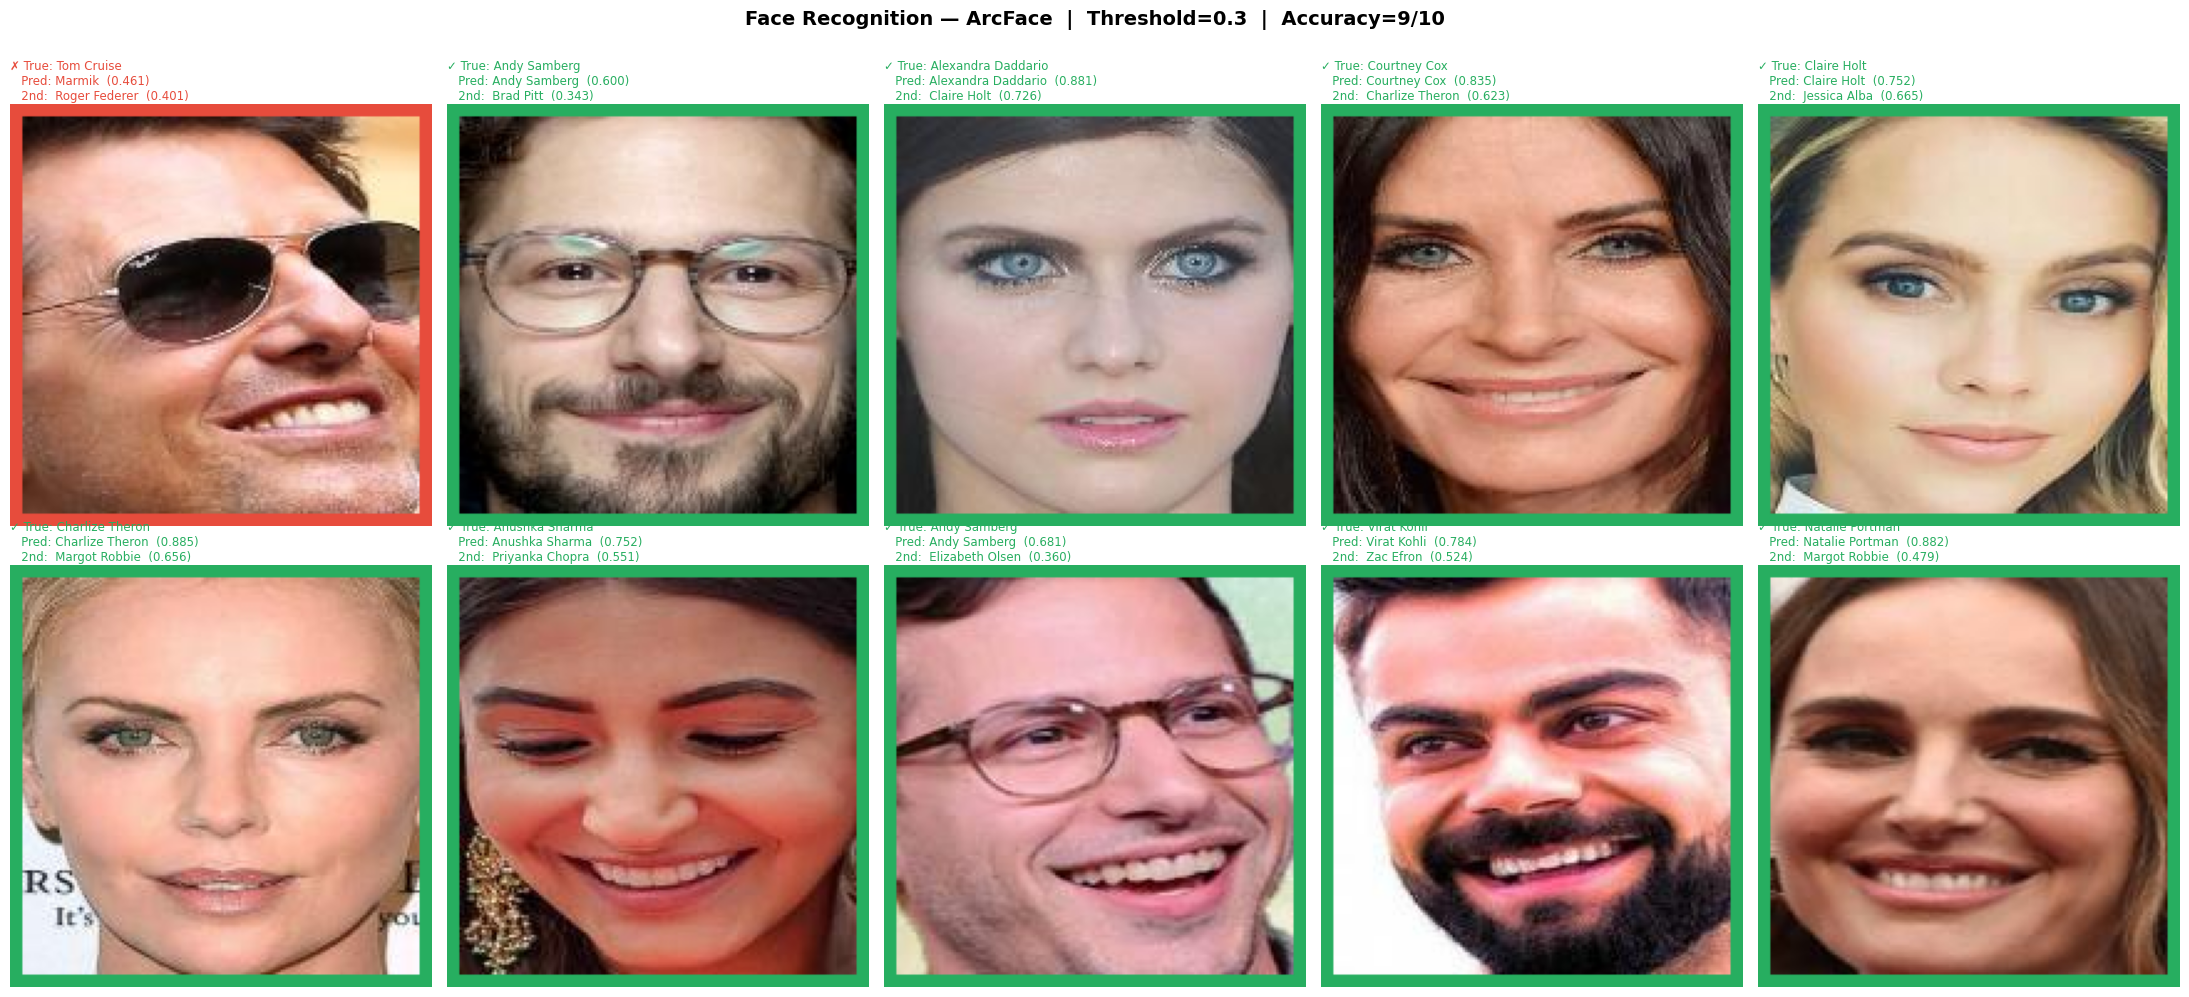


[INFO] Plot saved → /content/face_recognition_results.png

#    True Label                  Predicted                      Sim  OK?
1    Tom Cruise                  Marmik                      0.4606  ✗
2    Andy Samberg                Andy Samberg                0.5996  ✓
3    Alexandra Daddario          Alexandra Daddario          0.8807  ✓
4    Courtney Cox                Courtney Cox                0.8355  ✓
5    Claire Holt                 Claire Holt                 0.7516  ✓
6    Charlize Theron             Charlize Theron             0.8854  ✓
7    Anushka Sharma              Anushka Sharma              0.7517  ✓
8    Andy Samberg                Andy Samberg                0.6807  ✓
9    Virat Kohli                 Virat Kohli                 0.7844  ✓
10   Natalie Portman             Natalie Portman             0.8820  ✓
Accuracy on 10 random test images: 9/10  (90%)

[INFO] Generating similarity heatmap for test predictions …


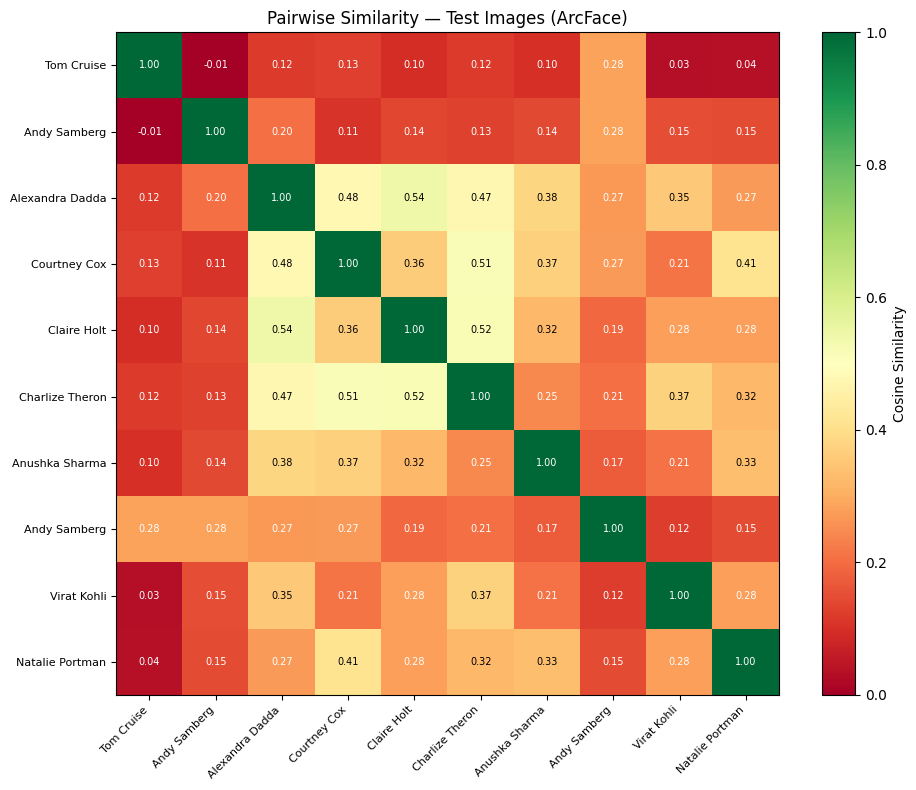

[INFO] Heatmap saved → /content/similarity_heatmap.png

[DONE] All done! 🎉


In [1]:
# ============================================================
# FACE RECOGNITION WITH ArcFace / VGG-Face2 (No FaceNet)
# GPU: T4 on Google Colab | Python 3.12+ compatible
# Dataset: Celebrities face dataset (49 images/celeb, MTCNN-detected)
# ============================================================
# PASTE THIS ENTIRE CELL INTO GOOGLE COLAB (Runtime > Run cell)
# Make sure: Runtime > Change runtime type > T4 GPU
# ============================================================

# ── 0. Install dependencies ──────────────────────────────────
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "deepface",
    "tf-keras",
    "opencv-python-headless",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "gdown"
], check=True)

# ── 1. Imports ───────────────────────────────────────────────
import os, random, warnings, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from tqdm import tqdm
import tensorflow as tf

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ── 2. GPU check ─────────────────────────────────────────────
gpus = tf.config.list_physical_devices("GPU")
print(f"[INFO] GPUs detected: {gpus if gpus else 'NONE — check runtime type!'}")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"[INFO] Using GPU: {gpus[0].name}")

# ── 3. Config ────────────────────────────────────────────────
DATASET_PATH  = "/content/drive/MyDrive/Datasets Models Projects/Faces"
MODEL_NAME    = "ArcFace"          # alternatives: "VGG-Face", "Facenet512", "SFace"
DETECTOR      = "skip"             # images are already MTCNN-cropped → skip detection
DISTANCE_METRIC = "cosine"
N_TEST        = 10                 # random test images
EMBEDDING_DIM = 512                # ArcFace output

# ── 4. Mount Google Drive ────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print(f"[INFO] Dataset path: {DATASET_PATH}")
assert os.path.isdir(DATASET_PATH), f"❌ Dataset not found at {DATASET_PATH}"

# ── 5. Build label → image paths index ──────────────────────
from deepface import DeepFace

label_to_paths = {}
for celeb in sorted(os.listdir(DATASET_PATH)):
    celeb_dir = os.path.join(DATASET_PATH, celeb)
    if not os.path.isdir(celeb_dir):
        continue
    imgs = [
        os.path.join(celeb_dir, f)
        for f in os.listdir(celeb_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    if imgs:
        label_to_paths[celeb] = imgs

print(f"[INFO] Found {len(label_to_paths)} celebrities")
print(f"       Labels: {list(label_to_paths.keys())[:8]} ...")

# ── 6. Build embedding gallery ───────────────────────────────
# For each celeb, compute mean embedding from up to 30 images (fast & robust)

def get_embedding(img_path: str) -> np.ndarray | None:
    """Return L2-normalised ArcFace embedding for one image."""
    try:
        result = DeepFace.represent(
            img_path    = img_path,
            model_name  = MODEL_NAME,
            detector_backend = DETECTOR,
            enforce_detection = False,
            align       = False,
        )
        vec = np.array(result[0]["embedding"], dtype=np.float32)
        return vec / (np.linalg.norm(vec) + 1e-10)
    except Exception as e:
        return None

print(f"\n[INFO] Building gallery with {MODEL_NAME} embeddings …")
t0 = time.time()

gallery = {}          # celeb → mean embedding
gallery_raw = {}      # celeb → list of embeddings (for diagnostics)

GALLERY_IMGS_PER_CELEB = 30   # use first N images to build reference

for celeb, paths in tqdm(label_to_paths.items(), desc="Gallery"):
    embs = []
    for p in paths[:GALLERY_IMGS_PER_CELEB]:
        e = get_embedding(p)
        if e is not None:
            embs.append(e)
    if embs:
        mean_emb = np.mean(embs, axis=0)
        mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-10)
        gallery[celeb] = mean_emb
        gallery_raw[celeb] = embs

print(f"[INFO] Gallery built in {time.time()-t0:.1f}s  ({len(gallery)} celebs)")

# Stack gallery into matrix for fast cosine similarity
celeb_names   = list(gallery.keys())
gallery_matrix = np.stack([gallery[c] for c in celeb_names])  # (N_celebs, 512)

# ── 7. Predict identity for one embedding ────────────────────
def predict_identity(emb: np.ndarray, top_k: int = 3):
    """Return list of (celeb, cosine_similarity) sorted desc."""
    sims = cosine_similarity(emb.reshape(1, -1), gallery_matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(celeb_names[i], float(sims[i])) for i in top_idx]

# ── 8. Sample 10 random test images ──────────────────────────
all_images = []   # (path, true_label)
for celeb, paths in label_to_paths.items():
    for p in paths:
        all_images.append((p, celeb))

random.seed(42)
test_samples = random.sample(all_images, min(N_TEST, len(all_images)))
print(f"\n[INFO] Testing on {len(test_samples)} random images …\n")

# ── 9. Run inference & visualise ─────────────────────────────
THRESHOLD = 0.30   # cosine similarity threshold for "known" vs "unknown"

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

results_log = []

for idx, (img_path, true_label) in enumerate(test_samples):
    emb = get_embedding(img_path)

    ax = axes[idx]
    img_bgr = cv2.imread(img_path)

    if img_bgr is None:
        ax.axis("off")
        ax.set_title("Could not load image", color="red", fontsize=9)
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    if emb is None:
        ax.imshow(img_rgb)
        ax.set_title(f"True: {true_label}\nPred: EMBEDDING ERROR",
                     color="red", fontsize=9, pad=4)
        ax.axis("off")
        results_log.append({"true": true_label, "pred": "ERROR", "correct": False})
        continue

    preds = predict_identity(emb, top_k=3)
    top_name, top_sim = preds[0]

    correct = (top_name == true_label)
    border_color = "#27ae60" if correct else "#e74c3c"

    # Draw image with colored border
    h, w = img_rgb.shape[:2]
    bordered = cv2.copyMakeBorder(img_rgb, 5, 5, 5, 5,
                                  cv2.BORDER_CONSTANT,
                                  value=([39,174,96] if correct else [231,76,60]))
    ax.imshow(bordered)
    ax.axis("off")

    status = "✓" if correct else "✗"
    title_color = "#27ae60" if correct else "#e74c3c"

    ax.set_title(
        f"{status} True: {true_label}\n"
        f"   Pred: {top_name}  ({top_sim:.3f})\n"
        f"   2nd:  {preds[1][0]}  ({preds[1][1]:.3f})",
        fontsize=8.5, color=title_color, loc="left", pad=3
    )

    results_log.append({"true": true_label, "pred": top_name,
                         "sim": top_sim, "correct": correct})
    print(f"[{idx+1:02d}] True={true_label:<25} Pred={top_name:<25} "
          f"Sim={top_sim:.4f}  {'✓ CORRECT' if correct else '✗ WRONG'}")

plt.suptitle(
    f"Face Recognition — {MODEL_NAME}  |  "
    f"Threshold={THRESHOLD}  |  "
    f"Accuracy={sum(r['correct'] for r in results_log)}/{len(results_log)}",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("/content/face_recognition_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[INFO] Plot saved → /content/face_recognition_results.png")

# ── 10. Summary table ────────────────────────────────────────
print("\n" + "="*70)
print(f"{'#':<4} {'True Label':<27} {'Predicted':<27} {'Sim':>6}  {'OK?'}")
print("="*70)
for i, r in enumerate(results_log):
    ok = "✓" if r["correct"] else "✗"
    sim = f"{r.get('sim', 0):.4f}"
    print(f"{i+1:<4} {r['true']:<27} {r['pred']:<27} {sim:>6}  {ok}")

n_correct = sum(r["correct"] for r in results_log)
print("="*70)
print(f"Accuracy on {len(results_log)} random test images: "
      f"{n_correct}/{len(results_log)}  ({100*n_correct/len(results_log):.0f}%)")

# ── 11. Similarity heatmap (bonus visualisation) ─────────────
print("\n[INFO] Generating similarity heatmap for test predictions …")

n = len(results_log)
sim_matrix = np.zeros((n, n))
test_embs = []

for img_path, _ in test_samples:
    e = get_embedding(img_path)
    test_embs.append(e if e is not None else np.zeros(EMBEDDING_DIM))

for i in range(n):
    for j in range(n):
        if test_embs[i] is not None and test_embs[j] is not None:
            sim_matrix[i, j] = float(
                cosine_similarity(
                    test_embs[i].reshape(1,-1),
                    test_embs[j].reshape(1,-1)
                )[0][0]
            )

fig2, ax2 = plt.subplots(figsize=(10, 8))
labels_short = [r["true"][:15] for r in results_log]
im = ax2.imshow(sim_matrix, cmap="RdYlGn", vmin=0, vmax=1)
ax2.set_xticks(range(n)); ax2.set_xticklabels(labels_short, rotation=45, ha="right", fontsize=8)
ax2.set_yticks(range(n)); ax2.set_yticklabels(labels_short, fontsize=8)
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f"{sim_matrix[i,j]:.2f}",
                 ha="center", va="center", fontsize=7,
                 color="black" if 0.3 < sim_matrix[i,j] < 0.7 else "white")
plt.colorbar(im, ax=ax2, label="Cosine Similarity")
ax2.set_title(f"Pairwise Similarity — Test Images ({MODEL_NAME})", fontsize=12)
plt.tight_layout()
plt.savefig("/content/similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Heatmap saved → /content/similarity_heatmap.png")
print("\n[DONE] All done! 🎉")

In [2]:
# ============================================================
# CELL 2 — Save ArcFace weights + gallery to Google Drive
# Run this immediately after Cell 1 succeeds
# ============================================================

import os, shutil, json, pickle
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/Datasets Models Projects/MyModels/ArcFace_FaceRecog"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"[INFO] Save destination: {SAVE_DIR}\n")

# ── 1. Copy ArcFace pretrained weights (.h5) ─────────────────
# DeepFace downloads weights to /root/.deepface/weights/
WEIGHTS_SRC = "/root/.deepface/weights/arcface_weights.h5"
WEIGHTS_DST = os.path.join(SAVE_DIR, "arcface_weights.h5")

if os.path.isfile(WEIGHTS_SRC):
    print("[1/4] Copying arcface_weights.h5 …", end=" ")
    shutil.copy2(WEIGHTS_SRC, WEIGHTS_DST)
    size_mb = os.path.getsize(WEIGHTS_DST) / 1e6
    print(f"done  ({size_mb:.1f} MB)")
else:
    print(f"[WARN] Weights not found at {WEIGHTS_SRC} — skipping")

# ── 2. Save gallery (mean embeddings dict) ───────────────────
GALLERY_PKL = os.path.join(SAVE_DIR, "gallery.pkl")
print("[2/4] Saving gallery.pkl …", end=" ")
with open(GALLERY_PKL, "wb") as f:
    pickle.dump(gallery, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"done  ({len(gallery)} celebs)")

# ── 3. Save gallery as .npy matrix + labels .json (fast load) ─
MATRIX_NPY  = os.path.join(SAVE_DIR, "gallery_matrix.npy")
LABELS_JSON = os.path.join(SAVE_DIR, "celeb_names.json")
print("[3/4] Saving gallery_matrix.npy + celeb_names.json …", end=" ")
np.save(MATRIX_NPY, gallery_matrix)
with open(LABELS_JSON, "w") as f:
    json.dump(celeb_names, f, indent=2)
print(f"done  (matrix shape: {gallery_matrix.shape})")

# ── 4. Save full raw embeddings per celeb (optional detail) ──
RAW_PKL = os.path.join(SAVE_DIR, "gallery_raw.pkl")
print("[4/4] Saving gallery_raw.pkl (all per-image embeddings) …", end=" ")
with open(RAW_PKL, "wb") as f:
    pickle.dump(gallery_raw, f, protocol=pickle.HIGHEST_PROTOCOL)
raw_count = sum(len(v) for v in gallery_raw.values())
print(f"done  ({raw_count} total embeddings)")

# ── Summary ───────────────────────────────────────────────────
print("\n" + "="*60)
print("✅  All files saved to Google Drive:")
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    mb = os.path.getsize(fpath) / 1e6
    print(f"   {fname:<35}  {mb:>7.2f} MB")
print("="*60)
print("\n💡 Next session: run Cell 3 (load) to restore everything instantly.")
print("   No re-training, no re-downloading needed.")

[INFO] Save destination: /content/drive/MyDrive/Datasets Models Projects/MyModels/ArcFace_FaceRecog

[1/4] Copying arcface_weights.h5 … done  (137.0 MB)
[2/4] Saving gallery.pkl … done  (31 celebs)
[3/4] Saving gallery_matrix.npy + celeb_names.json … done  (matrix shape: (31, 512))
[4/4] Saving gallery_raw.pkl (all per-image embeddings) … done  (930 total embeddings)

✅  All files saved to Google Drive:
   arcface_weights.h5                    137.03 MB
   celeb_names.json                        0.00 MB
   gallery.pkl                             0.06 MB
   gallery_matrix.npy                      0.06 MB
   gallery_raw.pkl                         1.93 MB

💡 Next session: run Cell 3 (load) to restore everything instantly.
   No re-training, no re-downloading needed.


In [3]:
# ============================================================
# CELL 3 — Load everything from Drive (future sessions)
# Run this INSTEAD of Cell 1 gallery-building step
# Restores in ~10 seconds instead of 13 minutes
# ============================================================

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "deepface", "tf-keras", "opencv-python-headless",
    "matplotlib", "scikit-learn", "tqdm"
], check=True)

import os, shutil, json, pickle, warnings
import numpy as np
import tensorflow as tf
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# GPU
gpus = tf.config.list_physical_devices("GPU")
print(f"[INFO] GPUs: {gpus}")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

SAVE_DIR = "/content/drive/MyDrive/Datasets Models Projects/MyModels/ArcFace_FaceRecog"
WEIGHTS_CACHE = "/root/.deepface/weights/arcface_weights.h5"

# ── Mount Drive ───────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ── 1. Restore weights so DeepFace never re-downloads ────────
os.makedirs("/root/.deepface/weights", exist_ok=True)
if not os.path.isfile(WEIGHTS_CACHE):
    src = os.path.join(SAVE_DIR, "arcface_weights.h5")
    print(f"[1/3] Restoring arcface_weights.h5 from Drive …", end=" ")
    shutil.copy2(src, WEIGHTS_CACHE)
    print(f"done  ({os.path.getsize(WEIGHTS_CACHE)/1e6:.1f} MB)")
else:
    print(f"[1/3] arcface_weights.h5 already in cache — skipping copy")

# ── 2. Load gallery (mean embeddings) ────────────────────────
print("[2/3] Loading gallery.pkl …", end=" ")
with open(os.path.join(SAVE_DIR, "gallery.pkl"), "rb") as f:
    gallery = pickle.load(f)
print(f"done  ({len(gallery)} celebs)")

# ── 3. Load matrix + labels ───────────────────────────────────
print("[3/3] Loading gallery_matrix.npy + celeb_names.json …", end=" ")
gallery_matrix = np.load(os.path.join(SAVE_DIR, "gallery_matrix.npy"))
with open(os.path.join(SAVE_DIR, "celeb_names.json")) as f:
    celeb_names = json.load(f)
print(f"done  (matrix: {gallery_matrix.shape})")

# ── Re-define helpers ─────────────────────────────────────────
from deepface import DeepFace
from sklearn.metrics.pairwise import cosine_similarity

MODEL_NAME = "ArcFace"
DETECTOR   = "skip"

def get_embedding(img_path):
    try:
        result = DeepFace.represent(
            img_path=img_path,
            model_name=MODEL_NAME,
            detector_backend=DETECTOR,
            enforce_detection=False,
            align=False,
        )
        vec = np.array(result[0]["embedding"], dtype=np.float32)
        return vec / (np.linalg.norm(vec) + 1e-10)
    except:
        return None

def predict_identity(emb, top_k=3):
    sims = cosine_similarity(emb.reshape(1, -1), gallery_matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(celeb_names[i], float(sims[i])) for i in top_idx]

print("\n✅  Everything restored! `gallery`, `gallery_matrix`, `celeb_names`,")
print("    `get_embedding()` and `predict_identity()` are ready.")
print("    You can now run the test/inference cells directly.")

[INFO] GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[1/3] arcface_weights.h5 already in cache — skipping copy
[2/3] Loading gallery.pkl … done  (31 celebs)
[3/3] Loading gallery_matrix.npy + celeb_names.json … done  (matrix: (31, 512))

✅  Everything restored! `gallery`, `gallery_matrix`, `celeb_names`,
    `get_embedding()` and `predict_identity()` are ready.
    You can now run the test/inference cells directly.
